# RetailPulse - Supermarket Sales Performance Analysis
**Question** Which branch, product line, payment mix and hour should a 3-store chain prioritize for staffing and promotions?

**Window** 1 January 2019 - 30 March 2019

**Role** Analyst reporting to the Head of the Store Operations

**Stack** pandas - numpy - seaborn - matplotlib

In [245]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [246]:
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 120

In [247]:
sales_raw = pd.read_csv("../data/supermarket_sales_raw.csv")

In [248]:
print("Shape:", sales_raw.shape)

Shape: (1012, 17)


In [249]:
print("First 5 rows:\n")
sales_raw.head()

First 5 rows:



,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,INV-10113,B,Mandalay,Normal,Male,Sports and travel,58.02,6,17.41,365.53,01/27/2019,20:51,Cash,348.12,4.761905,17.41,4.4
1,INV-10795,A,Yangon,Member,Male,Sports and travel,33.98,4,6.80,142.72,03/16/2019,16:19,Cash,135.92,4.761905,6.80,6.4
2,INV-10817,B,Mandalay,Member,Male,Food and beverages,38.03,3,5.70,119.79,01/27/2019,12:35,Credit card,114.09,4.761905,5.70,6.0
3,INV-10510,A,Yangon,Member,Female,Health and beauty,53.55,6,16.06,337.36,01/29/2019,18:36,Credit card,321.30,4.761905,16.06,6.7
4,INV-10492,B,Mandalay,Normal,Female,Health and beauty,78.96,1,3.95,82.91,01/01/2019,18:08,Ewallet,78.96,4.761905,3.95,4.8


In [250]:
print ("Column wise dtype\n")
print (sales_raw.dtypes)

Column wise dtype

Invoice ID                     str
Branch                         str
City                           str
Customer type                  str
Gender                         str
Product line                   str
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Total                      float64
Date                           str
Time                           str
Payment                        str
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object


In [251]:
print("Missing values per column:\n")
print(sales_raw.isna().sum())

Missing values per column:

Invoice ID                 0
Branch                     0
City                       0
Customer type              8
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     6
dtype: int64


In [252]:
print("Duplicate rows:\n")
print(sales_raw.duplicated().sum())

Duplicate rows:

12


In [253]:
print("Numeric Summery:\n")
print(sales_raw.describe().round(2))

Numeric Summery:

       Unit price  Quantity   Tax 5%    Total     cogs  gross margin percentage  gross income   Rating
count     1012.00   1012.00  1012.00  1012.00  1012.00                  1012.00       1012.00  1006.00
mean        50.60      5.39    13.70   287.62   273.92                     4.76         13.70     7.02
std         20.93      2.98     9.76   204.97   195.21                     0.00          9.76     1.72
min         13.38    -10.00   -29.20  -613.12  -583.92                     4.76        -29.20     4.00
25%         33.47      3.00     6.20   130.16   123.96                     4.76          6.20     5.50
50%         48.29      5.00    11.49   241.26   229.78                     4.76         11.49     7.00
75%         66.18      8.00    19.34   406.27   386.93                     4.76         19.34     8.50
max        101.22     10.00    45.31   951.52   906.21                     4.76         45.31    10.00


In [254]:
sales = sales_raw.copy()

In [255]:
print("Rows before cleaning: ", len(sales))

Rows before cleaning:  1012


In [256]:
before = len(sales)
sales = sales.drop_duplicates()
after = len(sales)
print(f"Dropped {before - after} duplicate rows")

Dropped 12 duplicate rows


In [257]:
print(f"Now {after} rows")

Now 1000 rows


In [258]:
sales.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,INV-10113,B,Mandalay,Normal,Male,Sports and travel,58.02,6,17.41,365.53,01/27/2019,20:51,Cash,348.12,4.761905,17.41,4.4
1,INV-10795,A,Yangon,Member,Male,Sports and travel,33.98,4,6.80,142.72,03/16/2019,16:19,Cash,135.92,4.761905,6.80,6.4
2,INV-10817,B,Mandalay,Member,Male,Food and beverages,38.03,3,5.70,119.79,01/27/2019,12:35,Credit card,114.09,4.761905,5.70,6.0
3,INV-10510,A,Yangon,Member,Female,Health and beauty,53.55,6,16.06,337.36,01/29/2019,18:36,Credit card,321.30,4.761905,16.06,6.7
4,INV-10492,B,Mandalay,Normal,Female,Health and beauty,78.96,1,3.95,82.91,01/01/2019,18:08,Ewallet,78.96,4.761905,3.95,4.8


In [259]:
sales["City"] = sales["City"].astype(str).str.strip().str.title()

In [260]:
sales["Payment"] = sales["Payment"].astype(str).str.strip().str.title()

In [261]:
sales["Payment"] = sales["Payment"].replace({"Credit Card":"Credit card"})

In [262]:
print("Unique Cities: ", sales["City"].unique())

Unique Cities:  <StringArray>
['Mandalay', 'Yangon', 'Naypyitaw']
Length: 3, dtype: str


In [263]:
print("Unique Payment Types: ", sales["Payment"].unique())

Unique Payment Types:  <StringArray>
['Cash', 'Credit card', 'Ewallet']
Length: 3, dtype: str


In [264]:
no_of_neg = (sales["Quantity"] < 0).sum()

In [265]:
print(f"Negative quantity rows: {no_of_neg}")

Negative quantity rows: 3


In [266]:
sales = sales[sales["Quantity"] > 0].copy()

In [267]:
print("Rows after dropping returns: ", len(sales))

Rows after dropping returns:  997


In [268]:
print(f"Customer type missing: {sales["Customer type"].isna().sum()}")

Customer type missing: 8


In [269]:
sales["Customer type"] = sales["Customer type"].fillna("Unknown")

In [270]:
median_rating = sales["Rating"].median()

In [271]:
print("Missing Rating: ", sales["Rating"].isna().sum())

Missing Rating:  6


In [272]:
sales["Rating"]=sales["Rating"].fillna(median_rating)

In [273]:
print("Missing values remaining: ")
print(sales.isna().sum())

Missing values remaining: 
Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64


In [274]:
sales.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,INV-10113,B,Mandalay,Normal,Male,Sports and travel,58.02,6,17.41,365.53,01/27/2019,20:51,Cash,348.12,4.761905,17.41,4.4
1,INV-10795,A,Yangon,Member,Male,Sports and travel,33.98,4,6.80,142.72,03/16/2019,16:19,Cash,135.92,4.761905,6.80,6.4
2,INV-10817,B,Mandalay,Member,Male,Food and beverages,38.03,3,5.70,119.79,01/27/2019,12:35,Credit card,114.09,4.761905,5.70,6.0
3,INV-10510,A,Yangon,Member,Female,Health and beauty,53.55,6,16.06,337.36,01/29/2019,18:36,Credit card,321.30,4.761905,16.06,6.7
4,INV-10492,B,Mandalay,Normal,Female,Health and beauty,78.96,1,3.95,82.91,01/01/2019,18:08,Ewallet,78.96,4.761905,3.95,4.8


In [275]:
sales["date"]= pd.to_datetime(sales["Date"], format="%m/%d/%Y")

In [276]:
sales["hour"]= pd.to_datetime(sales["Time"], format="%H:%M").dt.hour

In [277]:
sales["Day"]=sales["date"].dt.day_name()

In [278]:
sales["Month"]=sales["date"].dt.month_name()

In [279]:
sales.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,date,hour,Day,Month
0,INV-10113,B,Mandalay,Normal,Male,Sports and travel,58.02,6,17.41,365.53,01/27/2019,20:51,Cash,348.12,4.761905,17.41,4.4,2019-01-27,20,Sunday,January
1,INV-10795,A,Yangon,Member,Male,Sports and travel,33.98,4,6.80,142.72,03/16/2019,16:19,Cash,135.92,4.761905,6.80,6.4,2019-03-16,16,Saturday,March
2,INV-10817,B,Mandalay,Member,Male,Food and beverages,38.03,3,5.70,119.79,01/27/2019,12:35,Credit card,114.09,4.761905,5.70,6.0,2019-01-27,12,Sunday,January
3,INV-10510,A,Yangon,Member,Female,Health and beauty,53.55,6,16.06,337.36,01/29/2019,18:36,Credit card,321.30,4.761905,16.06,6.7,2019-01-29,18,Tuesday,January
4,INV-10492,B,Mandalay,Normal,Female,Health and beauty,78.96,1,3.95,82.91,01/01/2019,18:08,Ewallet,78.96,4.761905,3.95,4.8,2019-01-01,18,Tuesday,January


In [280]:
Revenue=sales["Total"].sum()
print("Gross revenue (incl. tax): ", Revenue)

Gross revenue (incl. tax):  289817.99


In [281]:
tax_collected = sales["Tax 5%"].sum()
print(f"Total tax collected: {tax_collected:.2f}")

Total tax collected: 13801.01


In [282]:
tickets=sales["Invoice ID"].nunique()
print("Number of unique invoices: ", tickets)

Number of unique invoices:  997


In [283]:
qty=sales["Quantity"].sum()
print("Total Quantity sold: ", qty)

Total Quantity sold:  5439


In [284]:
aov=sales["Total"].mean()
print("Average Order Value: ", aov)

Average Order Value:  290.6900601805416


In [285]:
avg_rating=sales["Rating"].mean()
print("Average rating: ", avg_rating)

Average rating:  7.014242728184555


In [286]:
date_lower_limit=sales["date"].min().date()

In [287]:
date_upper_limit=sales["date"].max().date()

In [288]:
print(f"The range for dates is {date_lower_limit} to {date_upper_limit}")

The range for dates is 2019-01-01 to 2019-03-30


In [289]:
products = (
    sales.groupby("Product line", as_index=False)
    .agg(
        Revenue=("Total", "sum"),
        Orders=("Invoice ID", "nunique"),
        Units=("Quantity", "sum"),
        Avg_rating=("Rating", "mean"),
        Tax_collected=("Tax 5%", "sum")
    )
    .sort_values("Revenue", ascending=False)
)

In [290]:
products

,Product line,Revenue,Orders,Units,Avg_rating,Tax_collected
1,Fashion accessories,59170.49,184,1044,6.814130,2817.70
0,Electronic accessories,54623.66,157,813,7.133121,2601.16
5,Sports and travel,52383.82,162,863,7.067901,2494.50
2,Food and beverages,44573.05,203,1124,6.899015,2122.60
3,Health and beauty,41366.45,150,842,6.942000,1969.84
4,Home and lifestyle,37700.52,141,753,7.324113,1795.21


In [291]:
products["Revenue_share_%"]=((products["Revenue"]/products["Revenue"].sum())*100).round(2)
products["Avg_rating"]=products["Avg_rating"].round(2)

In [292]:
products

,Product line,Revenue,Orders,Units,Avg_rating,Tax_collected,Revenue_share_%
1,Fashion accessories,59170.49,184,1044,6.81,2817.70,20.42
0,Electronic accessories,54623.66,157,813,7.13,2601.16,18.85
5,Sports and travel,52383.82,162,863,7.07,2494.50,18.07
2,Food and beverages,44573.05,203,1124,6.90,2122.60,15.38
3,Health and beauty,41366.45,150,842,6.94,1969.84,14.27
4,Home and lifestyle,37700.52,141,753,7.32,1795.21,13.01


In [293]:
order = products.sort_values("Revenue")

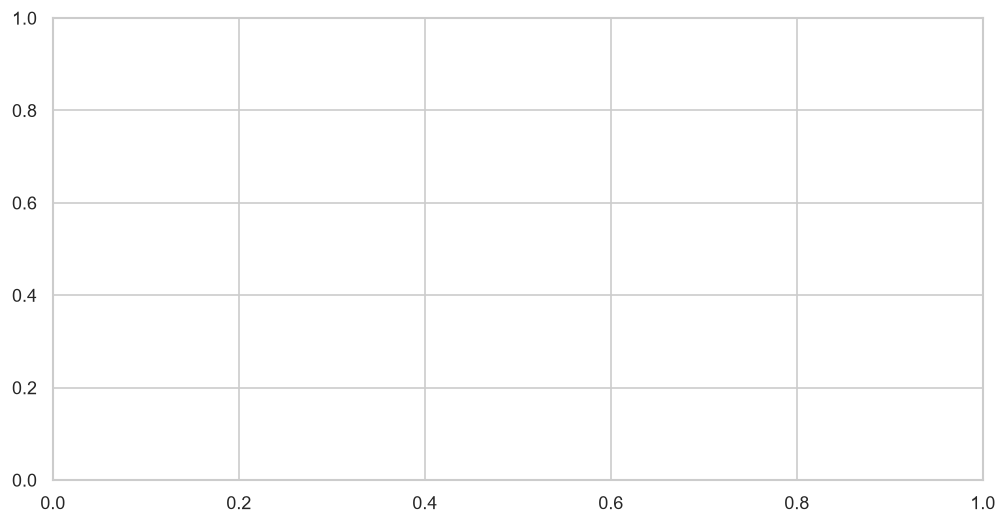

In [294]:
fig, ax=plt.subplots()

In [295]:
ax.barh(
    order["Product line"],
    order["Revenue"],
    color= sns.color_palette("Blues_d" , len(order))
)

<BarContainer object of 6 artists>

In [296]:
ax.set_xlabel("Revenue (incl. tax)")

Text(0.5, 5.333333333333337, 'Revenue (incl. tax)')

In [297]:
ax.set_title("Revenue by Product line")

Text(0.5, 1.0, 'Revenue by Product line')

In [298]:
order


,Product line,Revenue,Orders,Units,Avg_rating,Tax_collected,Revenue_share_%
4,Home and lifestyle,37700.52,141,753,7.32,1795.21,13.01
3,Health and beauty,41366.45,150,842,6.94,1969.84,14.27
2,Food and beverages,44573.05,203,1124,6.90,2122.60,15.38
5,Sports and travel,52383.82,162,863,7.07,2494.50,18.07
0,Electronic accessories,54623.66,157,813,7.13,2601.16,18.85
1,Fashion accessories,59170.49,184,1044,6.81,2817.70,20.42


In [299]:
for y,v in enumerate(order["Revenue"]):
    ax.text(v+80, y, f"${v: ,.0f}", va="center", fontsize=8)

In [300]:
fig.tight_layout()

In [301]:
fig.savefig("../figure/01_revenue_by_product.png" , dpi=140)

In [302]:
sales.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,date,hour,Day,Month
0,INV-10113,B,Mandalay,Normal,Male,Sports and travel,58.02,6,17.41,365.53,01/27/2019,20:51,Cash,348.12,4.761905,17.41,4.4,2019-01-27,20,Sunday,January
1,INV-10795,A,Yangon,Member,Male,Sports and travel,33.98,4,6.80,142.72,03/16/2019,16:19,Cash,135.92,4.761905,6.80,6.4,2019-03-16,16,Saturday,March
2,INV-10817,B,Mandalay,Member,Male,Food and beverages,38.03,3,5.70,119.79,01/27/2019,12:35,Credit card,114.09,4.761905,5.70,6.0,2019-01-27,12,Sunday,January
3,INV-10510,A,Yangon,Member,Female,Health and beauty,53.55,6,16.06,337.36,01/29/2019,18:36,Credit card,321.30,4.761905,16.06,6.7,2019-01-29,18,Tuesday,January
4,INV-10492,B,Mandalay,Normal,Female,Health and beauty,78.96,1,3.95,82.91,01/01/2019,18:08,Ewallet,78.96,4.761905,3.95,4.8,2019-01-01,18,Tuesday,January


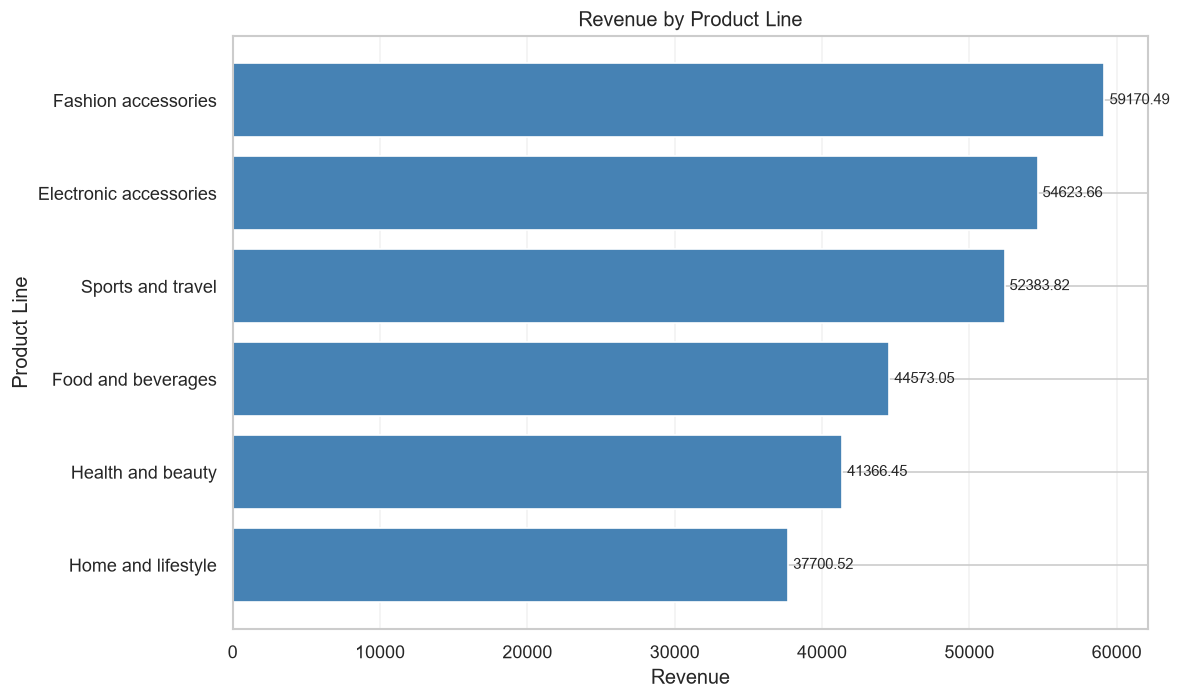

In [303]:
# Graph: Revenue by Product Line

fig, ax = plt.subplots(figsize=(10, 6))

order = products.sort_values("Revenue", ascending=True)

bars = ax.barh(
    order["Product line"],
    order["Revenue"],
    color="steelblue"
)

ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
ax.set_xlabel("Revenue")
ax.set_ylabel("Product Line")
ax.set_title("Revenue by Product Line")
ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

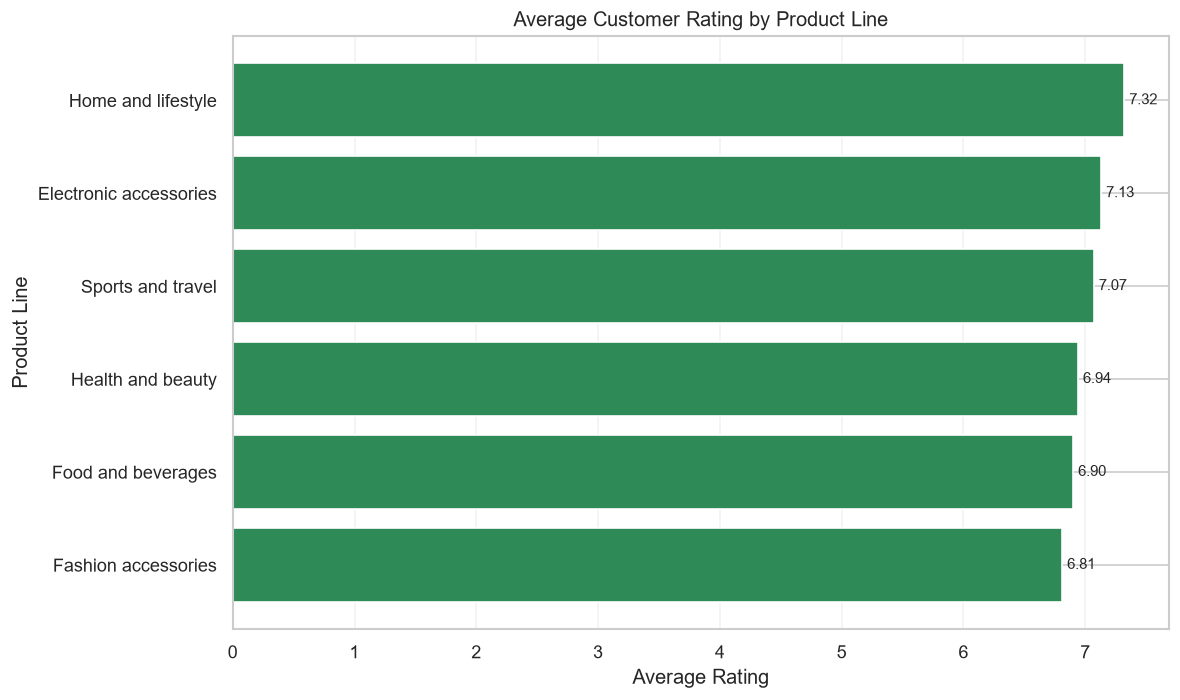

In [304]:
# Graph: Average Customer Rating by Product Line

fig, ax = plt.subplots(figsize=(10, 6))

order = products.sort_values("Avg_rating", ascending=True)

bars = ax.barh(
    order["Product line"],
    order["Avg_rating"],
    color="seagreen"
)

ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
ax.set_xlabel("Average Rating")
ax.set_ylabel("Product Line")
ax.set_title("Average Customer Rating by Product Line")
ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [305]:
branch=(
    sales.groupby("Branch" , as_index=False)
        .agg(
        Revenue=("Total" , "sum"),
        Orders=("Invoice ID" , "nunique"),
        Units=("Quantity" , "sum"),
        Avg_rating=("Rating" , "mean"),
        Tax_collected=("Tax 5%", "sum"),
        AOV=("Total", "mean")).sort_values("Revenue" , ascending=False)
)

In [306]:
branch["Revenue_share_%"]=((branch["Revenue"]/branch["Revenue"].sum())*100).round(2)
branch["Avg_rating"]=branch["Avg_rating"].round(2)

In [307]:
branch

,Branch,Revenue,Orders,Units,Avg_rating,Tax_collected,AOV,Revenue_share_%
0,A,117428.57,384,2163,7.05,5591.94,305.803568,40.52
1,B,89914.82,328,1710,6.99,4281.74,274.130549,31.02
2,C,82474.60,285,1566,7.00,3927.33,289.384561,28.46


In [308]:
branches=["A", "B", "C"]
revenue_share=[40.52,31.02,28.46]

Text(0.5, 1.0, 'Revenue Share per branch')

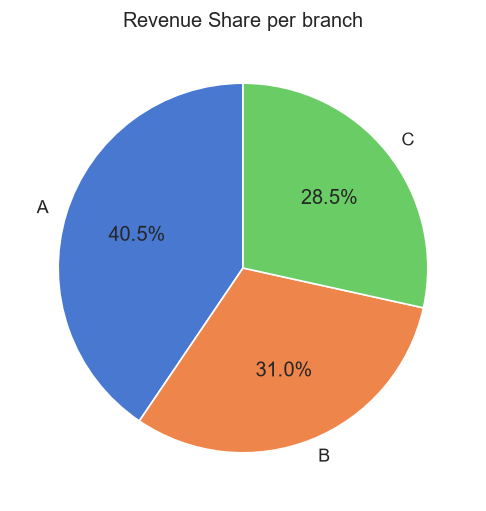

In [309]:
fig2=plt.pie(
    revenue_share,
    labels=branches,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Revenue Share per branch")

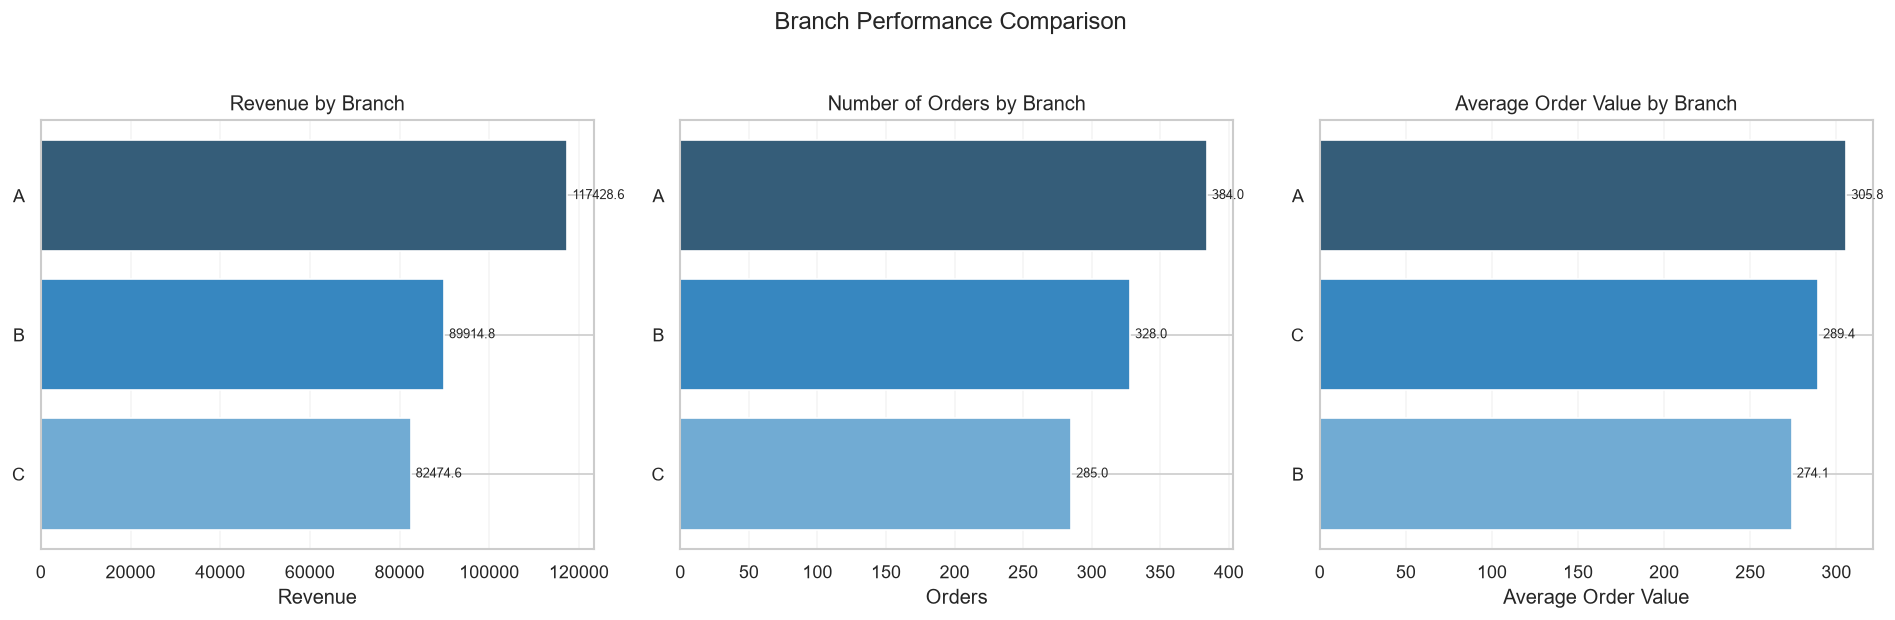

In [310]:

# KPI: Branch Performance
# Graph: Revenue, Orders and Average Order Value by Branch

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = [
    ("Revenue", "Revenue by Branch", "Revenue"),
    ("Orders", "Number of Orders by Branch", "Orders"),
    ("AOV", "Average Order Value by Branch", "Average Order Value")
]

for ax, (column, title, ylabel) in zip(axes, metrics):
    plot_data = branch.sort_values(column, ascending=True)

    bars = ax.barh(
        plot_data["Branch"],
        plot_data[column],
        color=sns.color_palette("Blues_d", len(plot_data))
    )

    ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=8)
    ax.set_title(title)
    ax.set_xlabel(ylabel)
    ax.grid(axis="x", alpha=0.2)
    ax.set_axisbelow(True)

plt.suptitle("Branch Performance Comparison", y=1.03)
plt.tight_layout()
plt.show()

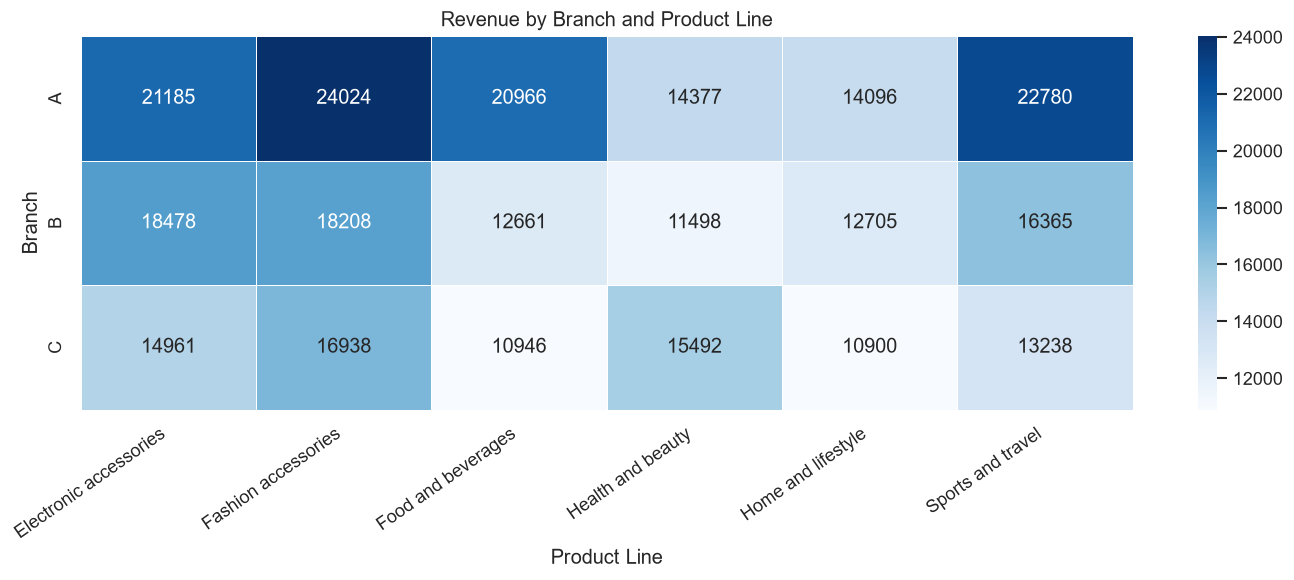

In [311]:

# KPI: Branch x Product Line
# Graph: Revenue Heatmap by Branch and Product Line

branch_product = sales.pivot_table(
    index="Branch",
    columns="Product line",
    values="Total",
    aggfunc="sum",
    fill_value=0
)

fig, ax = plt.subplots(figsize=(12, 5))

sns.heatmap(
    branch_product,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    linewidths=0.5,
    ax=ax
)

ax.set_title("Revenue by Branch and Product Line")
ax.set_xlabel("Product Line")
ax.set_ylabel("Branch")

plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

In [312]:
types_of_customers=(
    sales.groupby("Customer type" , as_index=False)
        .agg(
        Revenue=("Total" , "sum"),
        Orders=("Invoice ID" , "nunique"),
        Units=("Quantity" , "sum"),
        Avg_rating=("Rating" , "mean"),
        Tax_collected=("Tax 5%", "sum"),
        AOV=("Total", "mean")).sort_values("Revenue" , ascending=False)
)

In [313]:
types_of_customers["Revenue_share_%"]=((types_of_customers["Revenue"]/types_of_customers["Revenue"].sum())*100).round(2)
types_of_customers["Avg_rating"]=types_of_customers["Avg_rating"].round(2)

In [314]:
types_of_customers

,Customer type,Revenue,Orders,Units,Avg_rating,Tax_collected,AOV,Revenue_share_%
0,Member,150034.18,517,2861,7.05,7144.56,290.201509,51.77
1,Normal,137370.37,472,2534,6.99,6541.52,291.038919,47.40
2,Unknown,2413.44,8,44,6.32,114.93,301.680000,0.83


Text(0.5, 1.0, 'Revenue by Customer Type')

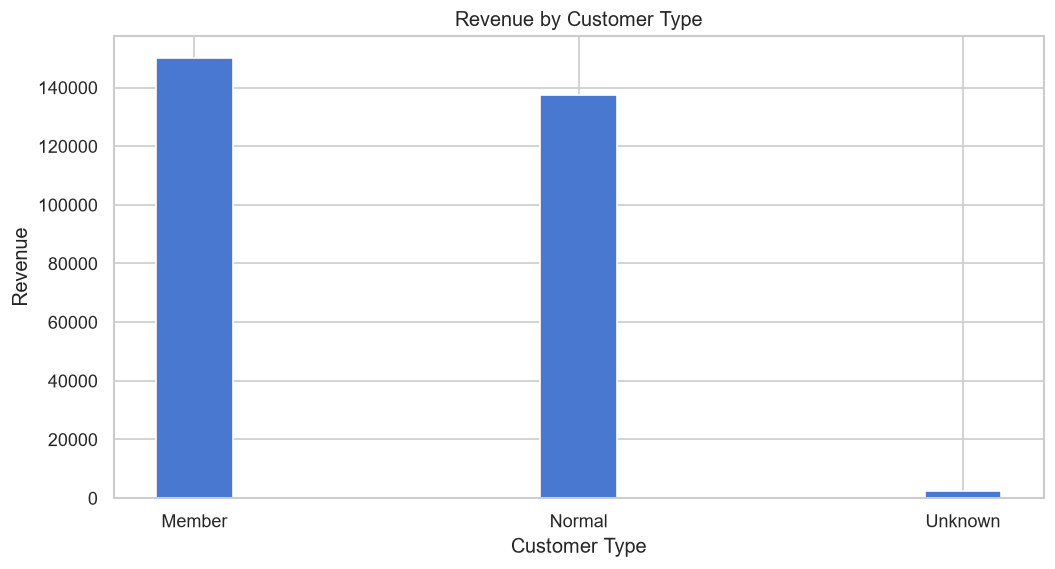

In [315]:
x=["Member", "Normal", "Unknown"]
y= [150034.18, 137370.37, 2413.44]

plt.bar(x, y, width=0.2)
plt.xlabel("Customer Type")
plt.ylabel("Revenue")
plt.title("Revenue by Customer Type")

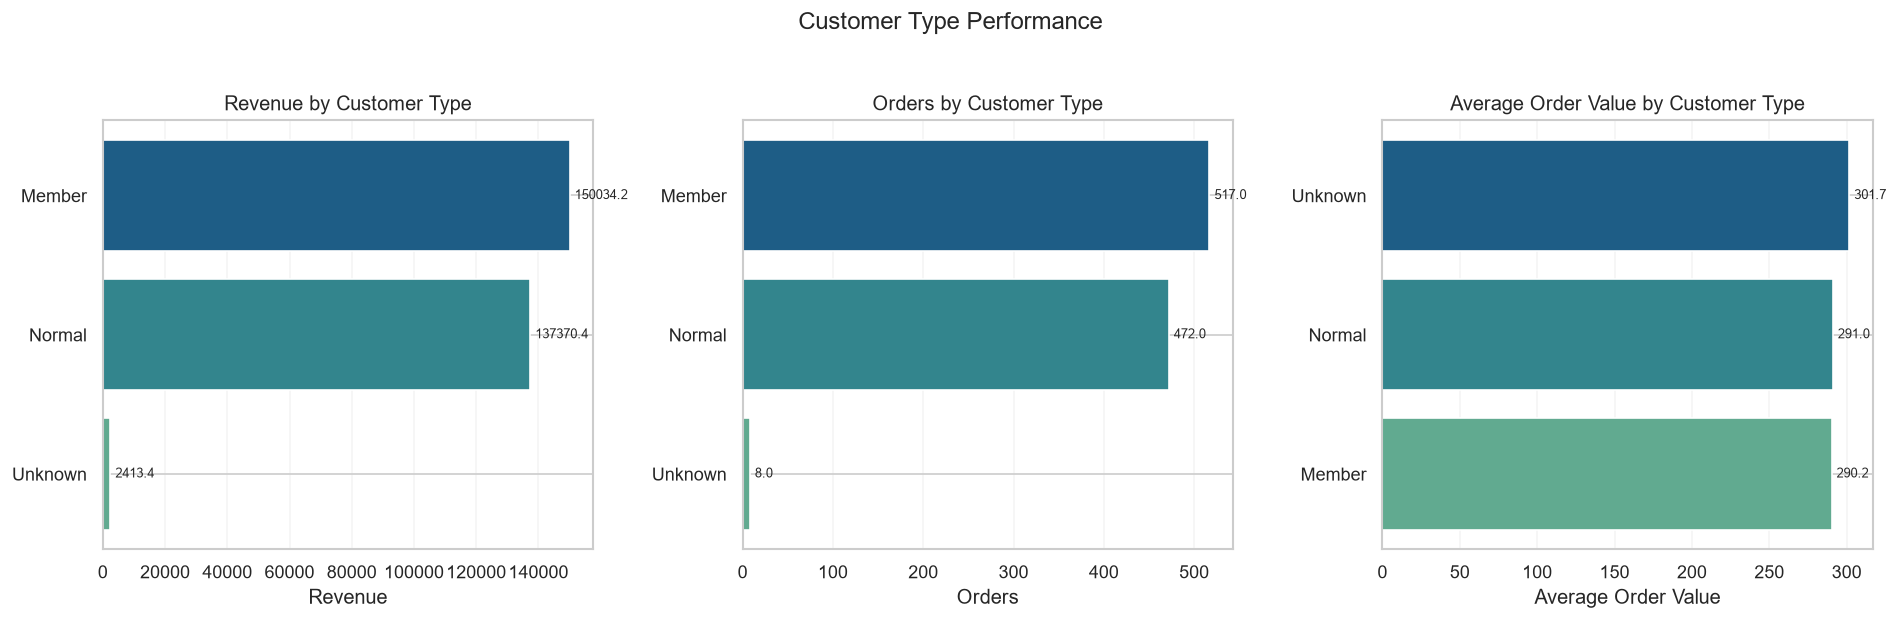

In [316]:

# KPI: Customer Type
# Graph : Revenue, Orders and AOV by Customer Type

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = [
    ("Revenue", "Revenue by Customer Type", "Revenue"),
    ("Orders", "Orders by Customer Type", "Orders"),
    ("AOV", "Average Order Value by Customer Type", "Average Order Value")
]

for ax, (column, title, ylabel) in zip(axes, metrics):
    plot_data = types_of_customers.sort_values(
        column, ascending=True
    )

    bars = ax.barh(
        plot_data["Customer type"],
        plot_data[column],
        color=sns.color_palette("crest", len(plot_data))
    )

    ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=8)
    ax.set_title(title)
    ax.set_xlabel(ylabel)
    ax.grid(axis="x", alpha=0.2)
    ax.set_axisbelow(True)

plt.suptitle("Customer Type Performance", y=1.03)
plt.tight_layout()
plt.show()

In [317]:
gender=(
    sales.groupby("Gender" , as_index=False)
        .agg(
        Revenue=("Total" , "sum"),
        Orders=("Invoice ID" , "nunique"),
        Units=("Quantity" , "sum"),
        Avg_rating=("Rating" , "mean"),
        Tax_collected=("Tax 5%", "sum"),
        AOV=("Total", "mean")).sort_values("Revenue" , ascending=False)
)

In [318]:
gender["Revenue_share_%"]=((gender["Revenue"]/gender["Revenue"].sum())*100).round(2)
gender["Avg_rating"]=gender["Avg_rating"].round(2)

In [319]:
gender

,Gender,Revenue,Orders,Units,Avg_rating,Tax_collected,AOV,Revenue_share_%
0,Female,150978.78,518,2840,6.98,7189.53,291.464826,52.09
1,Male,138839.21,479,2599,7.05,6611.48,289.852213,47.91


In [320]:
gender=["Female", "Male"]
revenue_share=[52.09,47.91]

Text(0.5, 1.0, 'Revenue Share of each Gender')

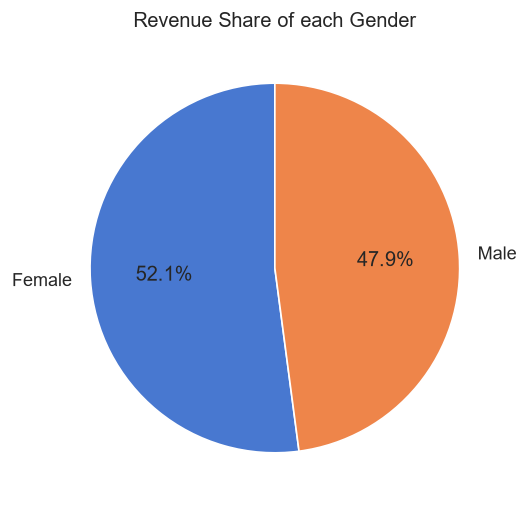

In [321]:
plt.pie(
    revenue_share,
    labels=gender,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Revenue Share of each Gender")

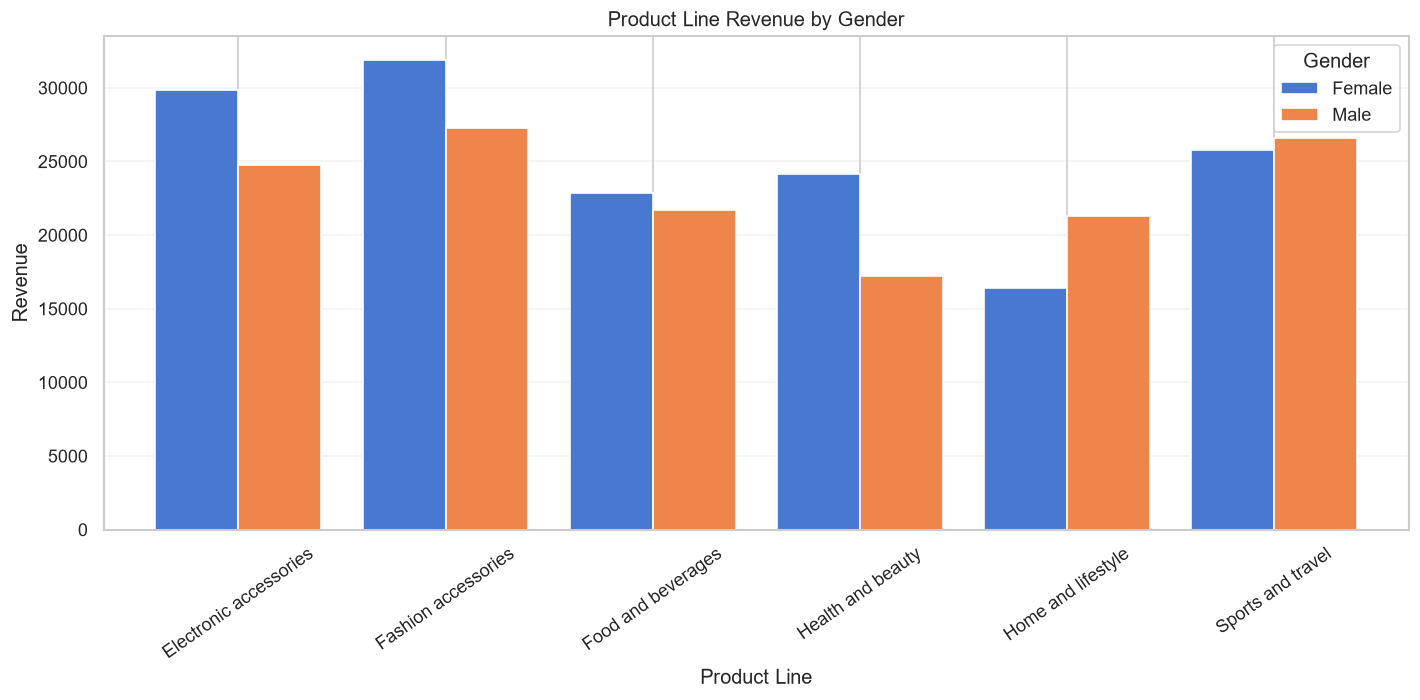

In [322]:

# KPI: Gender
# Graph : Product Line Revenue by Gender

gender_product = sales.pivot_table(
    index="Product line",
    columns="Gender",
    values="Total",
    aggfunc="sum",
    fill_value=0
)

fig, ax = plt.subplots(figsize=(12, 6))

gender_product.plot(
    kind="bar",
    ax=ax,
    width=0.8
)

ax.set_title("Product Line Revenue by Gender")
ax.set_xlabel("Product Line")
ax.set_ylabel("Revenue")
ax.legend(title="Gender")
ax.tick_params(axis="x", rotation=35)
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [323]:
payment_mix=(
    sales.groupby("Payment" , as_index=False)
        .agg(
        Revenue=("Total" , "sum"),
        Orders=("Invoice ID" , "nunique"),
        Units=("Quantity" , "sum"),
        Avg_rating=("Rating" , "mean"),
        Tax_collected=("Tax 5%", "sum")).sort_values("Revenue" , ascending=False)
)

In [324]:
payment_mix["Revenue_share_%"]=((payment_mix["Revenue"]/payment_mix["Revenue"].sum())*100).round(2)
payment_mix["Avg_rating"]=payment_mix["Avg_rating"].round(2)

In [325]:
payment_mix

,Payment,Revenue,Orders,Units,Avg_rating,Tax_collected,Revenue_share_%
0,Cash,107115.04,369,2019,7.02,5100.78,36.96
2,Ewallet,95470.94,336,1778,6.97,4546.29,32.94
1,Credit card,87232.01,292,1642,7.06,4153.94,30.10


Text(0.5, 1.0, 'Revenue by Payment Type')

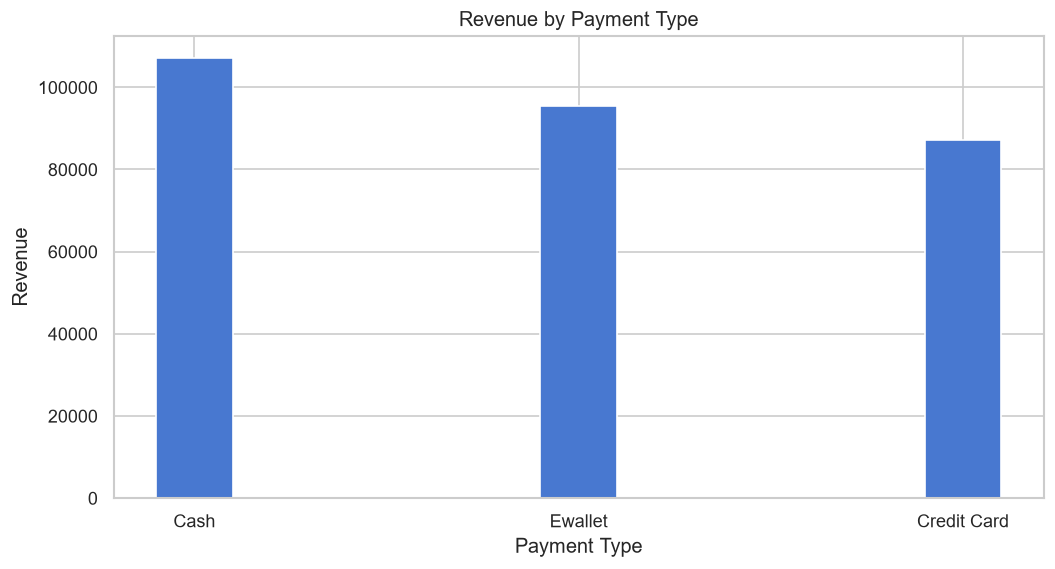

In [326]:
x=["Cash", "Ewallet", "Credit Card"]
y=[107115.04, 95470.94, 87232.01]

plt.bar(x, y, width=0.2)
plt.xlabel("Payment Type")
plt.ylabel("Revenue")
plt.title("Revenue by Payment Type")

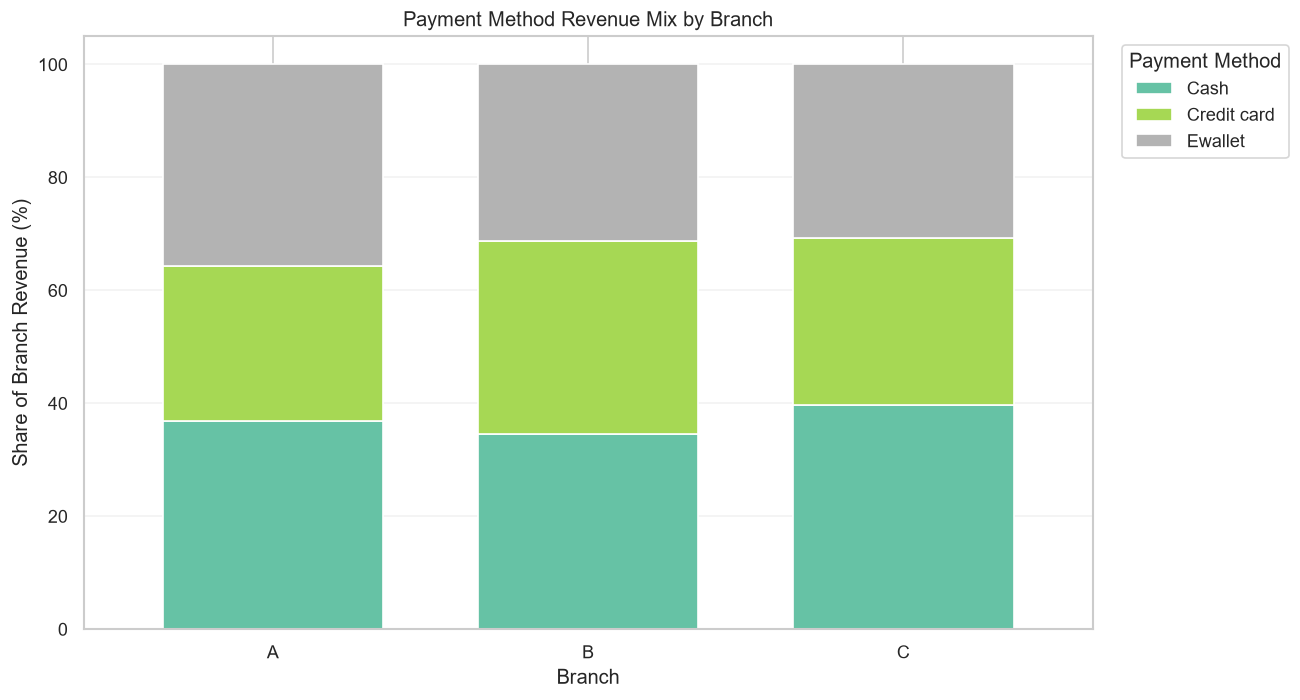

In [327]:

# KPI: Payment Mix
# Graph : Payment Method Revenue Share within Each Branch

payment_branch = sales.pivot_table(
    index="Branch",
    columns="Payment",
    values="Total",
    aggfunc="sum",
    fill_value=0
)

payment_branch_share = payment_branch.div(
    payment_branch.sum(axis=1),
    axis=0
) * 100

ax = payment_branch_share.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6),
    colormap="Set2",
    width=0.7
)

ax.set_title("Payment Method Revenue Mix by Branch")
ax.set_xlabel("Branch")
ax.set_ylabel("Share of Branch Revenue (%)")
ax.legend(title="Payment Method", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [328]:

# KPI: Time and Demand
# Graph : Hourly Revenue and Order Volume

hourly = (
    sales.groupby("hour")
    .agg(
        Revenue=("Total", "sum"),
        Orders=("Invoice ID", "nunique"),
        Units=("Quantity", "sum")
    )
    .reindex(range(7, 24), fill_value=0)
    .rename_axis("hour")
    .reset_index()
)



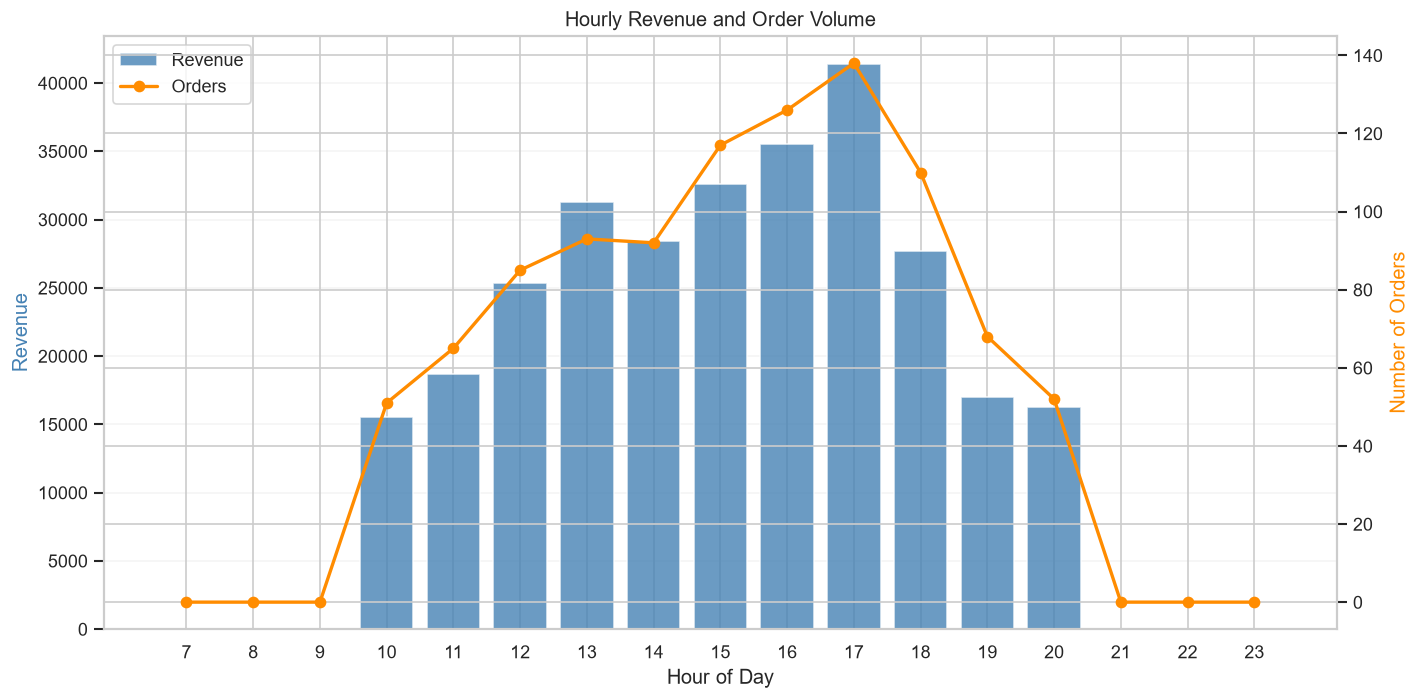

In [329]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(
    hourly["hour"],
    hourly["Revenue"],
    color="steelblue",
    alpha=0.8,
    label="Revenue"
)

ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Revenue", color="steelblue")
ax1.set_xticks(range(7, 24))
ax1.set_title("Hourly Revenue and Order Volume")
ax1.grid(axis="y", alpha=0.2)
ax1.set_axisbelow(True)

ax2 = ax1.twinx()

ax2.plot(
    hourly["hour"],
    hourly["Orders"],
    color="darkorange",
    marker="o",
    linewidth=2,
    label="Orders"
)

ax2.set_ylabel("Number of Orders", color="darkorange")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [330]:

# KPI: Staffing and Demand
# Graph: Revenue Heatmap by Day and Hour

day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

hour_day = sales.pivot_table(
    index="Day",
    columns="hour",
    values="Total",
    aggfunc="sum",
    fill_value=0
)

hour_day = hour_day.reindex(day_order, fill_value=0)
hour_day = hour_day.reindex(columns=range(7, 24), fill_value=0)



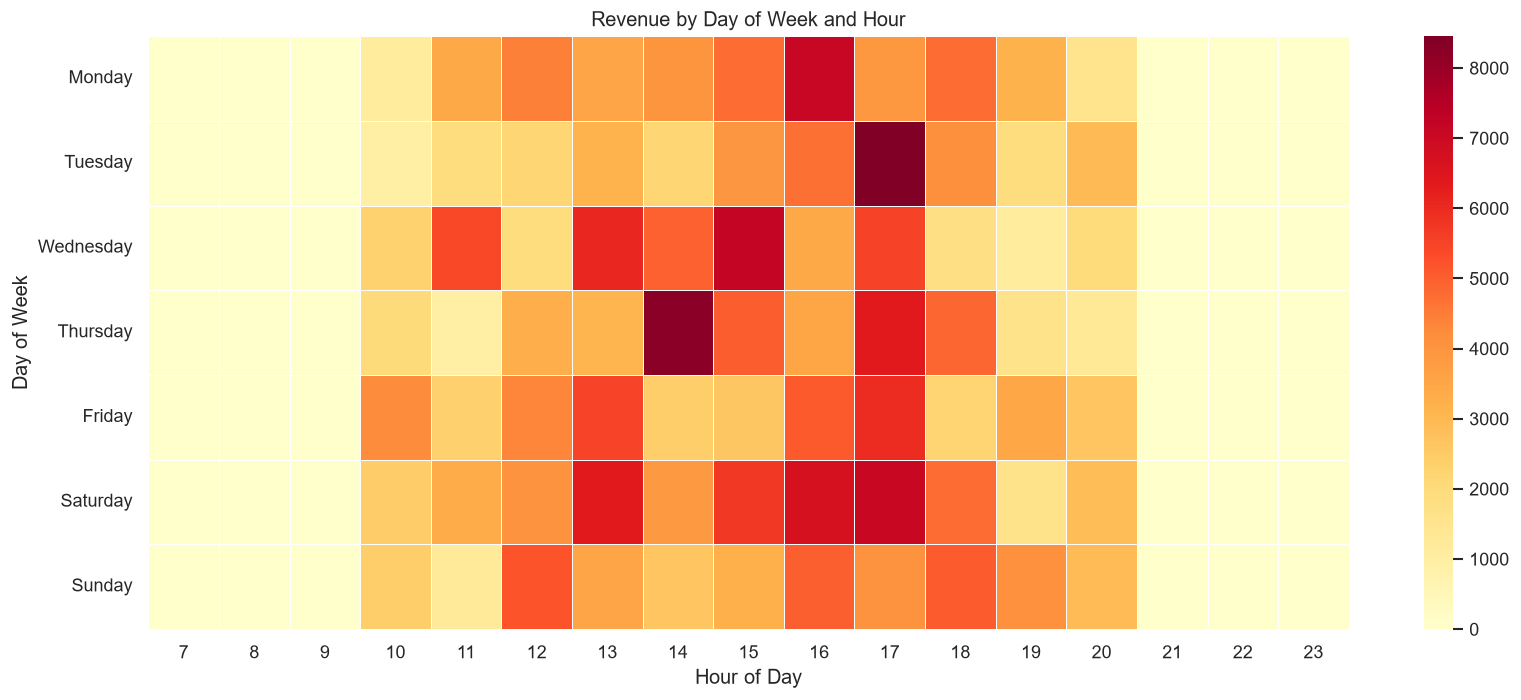

In [331]:
fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(
    hour_day,
    cmap="YlOrRd",
    linewidths=0.3,
    ax=ax
)

ax.set_title("Revenue by Day of Week and Hour")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Day of Week")

plt.tight_layout()
plt.show()

In [332]:

# KPI: Sales Trend
# Graph : Daily Revenue with 7-Day Rolling Average

daily = (
    sales.groupby("date", as_index=False)
    .agg(
        Revenue=("Total", "sum"),
        Orders=("Invoice ID", "nunique")
    )
    .sort_values("date")
)

In [333]:

daily["Revenue_7day_avg"] = (
    daily["Revenue"]
    .rolling(window=7, min_periods=1)
    .mean()
)

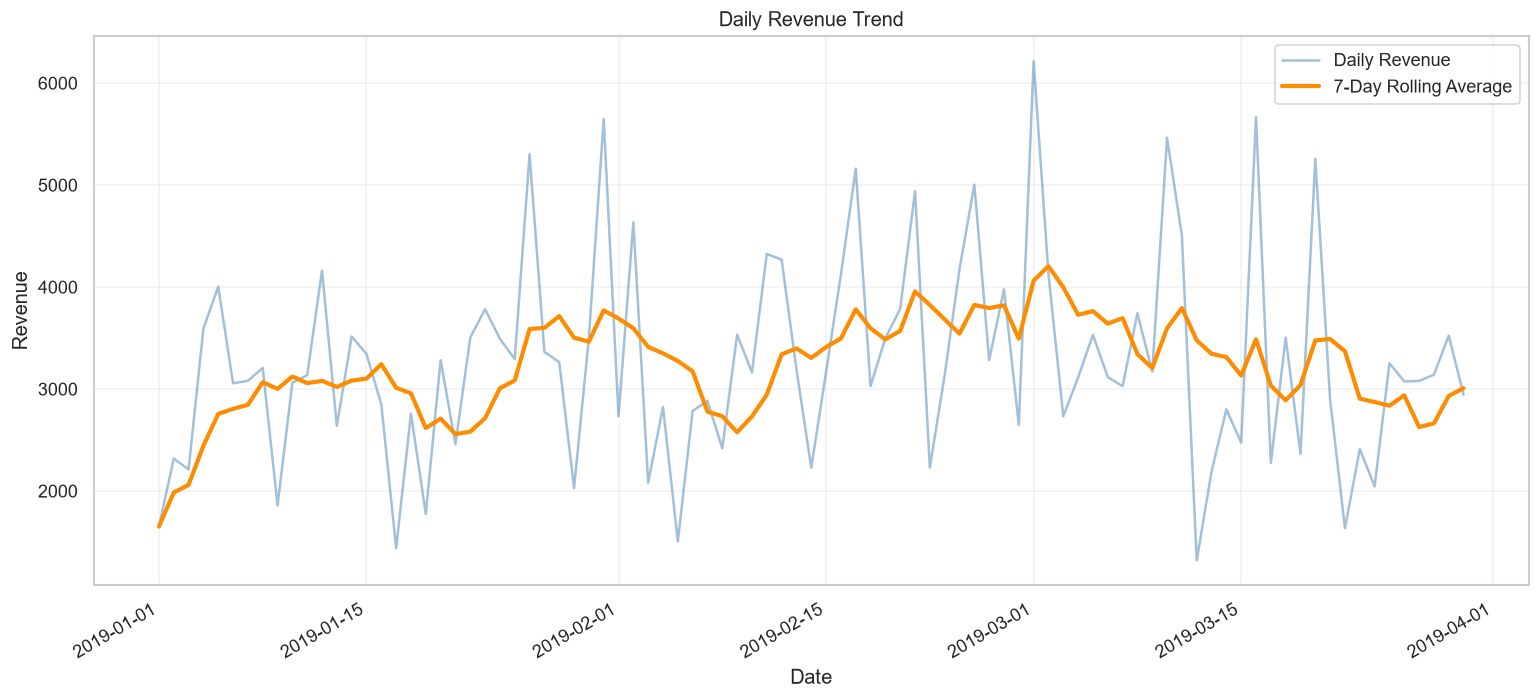

In [334]:
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(
    daily["date"],
    daily["Revenue"],
    color="steelblue",
    alpha=0.5,
    label="Daily Revenue"
)

ax.plot(
    daily["date"],
    daily["Revenue_7day_avg"],
    color="darkorange",
    linewidth=2.5,
    label="7-Day Rolling Average"
)

ax.set_title("Daily Revenue Trend")
ax.set_xlabel("Date")
ax.set_ylabel("Revenue")
ax.legend()
ax.grid(alpha=0.25)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

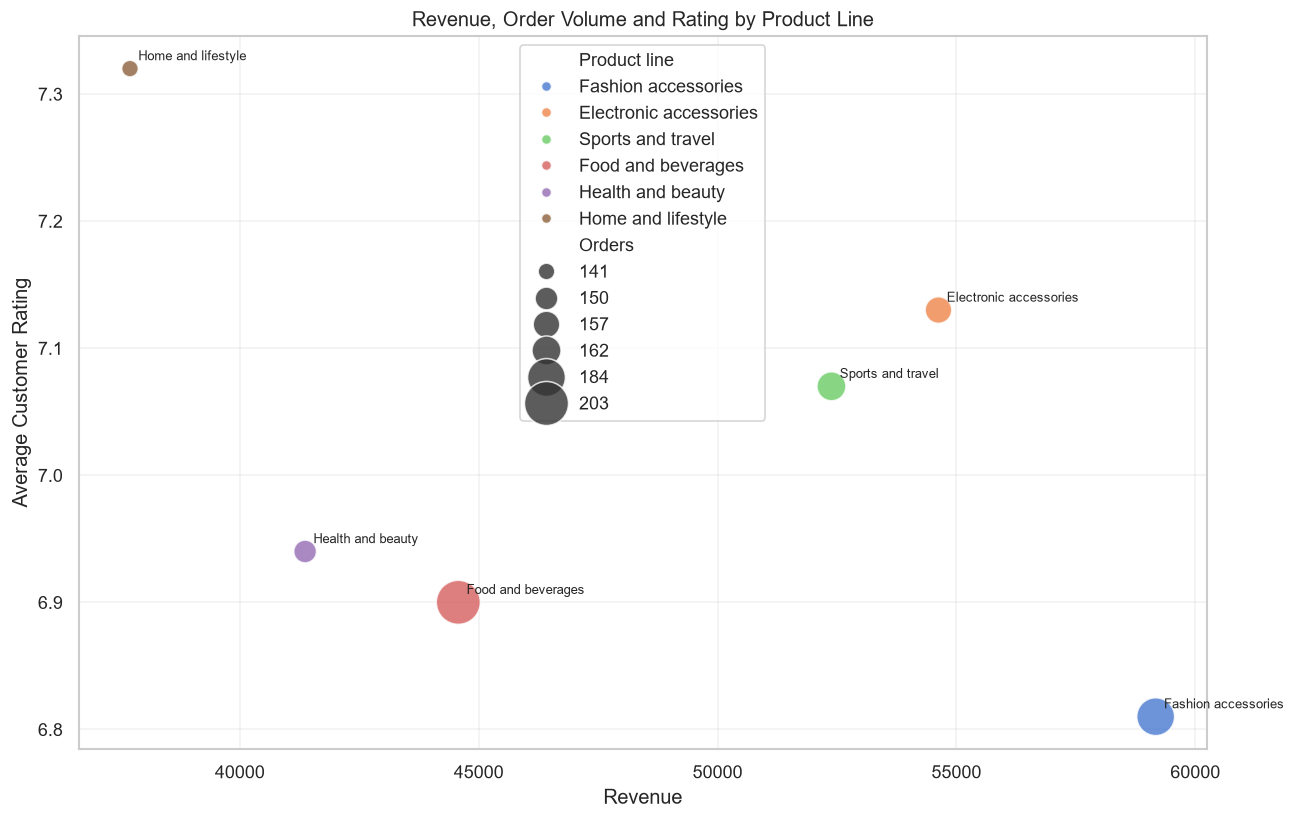

In [335]:

# KPI: Customer Satisfaction
# Graph: Revenue vs Average Rating by Product Line

fig, ax = plt.subplots(figsize=(11, 7))

sns.scatterplot(
    data=products,
    x="Revenue",
    y="Avg_rating",
    size="Orders",
    hue="Product line",
    sizes=(100, 700),
    alpha=0.8,
    ax=ax
)

for _, row in products.iterrows():
    ax.annotate(
        row["Product line"],
        (row["Revenue"], row["Avg_rating"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

ax.set_title("Revenue, Order Volume and Rating by Product Line")
ax.set_xlabel("Revenue")
ax.set_ylabel("Average Customer Rating")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


## Key Insights and Business Recommendations

### 1. Overall Sales Performance
- Generated total revenue of **289,817.99** from **997 unique invoices** and **5,439 units sold** during the analysis period.
- The average customer rating was approximately **7.01/10**, providing a baseline for evaluating customer satisfaction.
- Total tax collected was **13,801.01**. The `gross income` column represents tax collected, not gross profit.

### 2. Product-Line Performance
- **Fashion accessories** generated the highest revenue at **59,170.49**, contributing approximately 20.42% of total revenue.
- **Home and lifestyle** recorded the lowest revenue at **37,700.52**, despite having the highest average customer rating of **7.32**.
- **Food and beverages** recorded the highest order count (**203**) and units sold (**1,124**).
- **Recommendation:** Investigate customer feedback for fashion accessories and explore targeted promotions to improve sales of home and lifestyle products.

### 3. Branch Performance
- **Branch A** led sales, generating **117,428.57** in revenue, approximately 40.52% of the total.
- **Branch B** generated **89,914.82** in revenue and had the lowest average order value of **274.13**.
- **Branch C** generated **82,474.60** in revenue.
- **Recommendation:** Compare product mix and purchasing patterns across branches to identify opportunities to increase average order value and improve sales performance.

### 4. Customer Segmentation
- **Members** contributed **150,034.18** in revenue, approximately 51.77% of the total.
- Normal customers contributed **137,370.37**, or approximately 47.40% of total revenue.
- Female customers contributed approximately **52.09%** of revenue, compared with **47.91%** from male customers.
- **Recommendation:** Evaluate membership effectiveness through repeat purchases and retention, rather than revenue alone.

### 5. Payment Preferences
- Cash accounted for **36.96%** of revenue, e-wallets for **32.94%**, and credit cards for **30.10%**.
- Digital payment methods together accounted for **63.04%** of total revenue.
- **Recommendation:** Maintain convenient payment options across cash and digital methods to support different customer preferences.

### 6. Time-Based Sales Analysis
- Hourly revenue trends and day-and-hour visualizations can help identify busy periods and support staffing and inventory planning.
- Daily sales trends can help reveal fluctuations in demand over the analysis period.
- **Recommendation:** Use the observed peak periods and recurring sales patterns to improve operational planning.

### 7. Overall Conclusion
The analysis highlights differences in revenue contribution, customer ratings, branch performance, customer segments, and payment preferences. These findings can support data-driven decisions regarding product promotion, customer retention, and operational planning.

**Limitation:** The dataset supports sales and tax analysis but does not provide sufficient cost and expense information to calculate actual business profit.